# PTM: trial-by-trial matching of segmented EEG and E-Prime behavior

For every subject and event (`Cue`, `FB`) this notebook builds two objects whose trial axes line up exactly:

| object | shape | what it is |
|---|---|---|
| `eeg[event]` | channel × trial × time (`xarray.DataArray`) | the BrainVision-exported segments that survived artifact rejection |
| `beh[event]` | trial × variable (`DataFrame`) | the selected E-Prime variables for exactly those trials, same order |

It also builds `beh_full`: all 576 training trials per subject, with a flag and index for whether each trial has a Cue / FB epoch. **Fit computational models on `beh_full`** (learning depends on every trial, including ones whose EEG was rejected), then subset the trial-level model outputs with `in_Cue` / `in_FB`.

### How the matching works
1. **E-Prime → expected marker codes.** Each training trial's cue code (`S11–S26` = side × cue image) and feedback code (`S6x/7x/8x/9x` = side × reward × cue image) are rebuilt from the E-Prime log using `study_info/PTM_marker.xlsx`.
2. **Raw `.vmrk` ↔ E-Prime.** The cue and feedback markers in the raw recording must reproduce that sequence exactly, one per trial. This ties every raw marker (and its sample position) to an E-Prime trial number.
3. **Exported segments ↔ raw markers.** The exported `.mat` holds only the surviving segments, in order, each with its code but **no original time stamp**. The codes alone are ambiguous when a dropped trial sits in a run of identical codes (e.g. `S16 S16`). So every exported segment is also correlated with the raw EEG at each candidate marker (1–20 Hz, average reference, grand-average ERP removed), and an order-preserving alignment picks the path that matches codes and maximizes total correlation. Correct pairs correlate at about r = .8, wrong ones at about .1, so the choice is unambiguous. The diagnostics table reports how many segments the codes alone could not place, and the correlation margin for each.

## 1. Config

In [2]:
import re
from difflib import SequenceMatcher
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import xarray as xr
from scipy.signal import butter, sosfiltfilt

# ---- paths ---------------------------------------------------------------
ROOT      = Path(r"C:\Yifan\thesis\PTM\study3\data")
EXPORT    = ROOT / "EEG" / "exportfiles_v4"      # <sub>_<event>_Seg.mat
RAW       = ROOT / "EEG" / "rawdata"             # PTM_<sub>.vhdr/.vmrk/.eeg
EPRIME    = ROOT / "Eprime"                      # PTM_*-<sub>-1.txt
OUT       = ROOT / "EEG_behav_trialwise"

SUBJECTS  = ["0020", "0021"]    # None -> every subject with both Cue and FB exports
EVENTS    = ["Cue", "FB"]

# ---- behavior variables to keep -------------------------------------------
# E-Prime column -> new name. Derived columns (block, cue, reward, side, codes, ...)
# are always added; edit this dict to carry extra raw E-Prime columns along.
EPRIME_VARS = {
    "TrainingTrials.Sample": "trial",      # 1..576, the key used everywhere
    "trialtype":             "trialtype",  # e.g. BNR = cue B, no reward
    "ImageDisplay3.RESP":    "resp",       # 1 = left, 5 = right
    "ImageDisplay3.RT":      "rt",
    "prediction":            "cue_img",
    "feedback":              "fb_img",
}

# ---- marker scheme (study_info/PTM_marker.xlsx) ---------------------------
ATTR_IDX  = {"blusq": 1, "blutri": 2, "blucir": 3, "yelsq": 4, "yeltri": 5, "yelcir": 6}
CUE_BASE  = {"L": 10, "R": 20}                                   # S1x / S2x
FB_BASE   = {("L", 1): 60, ("L", 0): 70, ("R", 1): 80, ("R", 0): 90}
CODE_RANGE = {"Cue": (11, 26), "FB": (61, 96)}

# ---- matching ----------------------------------------------------------------
MATCH_BAND   = (1, 20)                       # Hz, only used for matching
NON_SCALP    = {"VEOG", "HEOG", "LM", "RM", "LH", "RH"}
MIN_R_WARN   = 0.25                          # flag matched pairs below this

OUT.mkdir(exist_ok=True)

## 2. Behavior: E-Prime text log → one row per training trial

In [3]:
def read_eprime_txt(path):
    '''Parse an E-Prime .txt log (UTF-16) into one row per LogFrame, in file order.'''
    frames, cur, level = [], None, None
    for line in Path(path).read_text(encoding="utf-16").splitlines():
        s = line.strip()
        if s.startswith("Level:"):
            level = int(s.split(":")[1])
        elif s == "*** LogFrame Start ***":
            cur = {"Level": level}
        elif s == "*** LogFrame End ***":
            frames.append(cur); cur = None
        elif cur is not None and ":" in s:
            k, v = s.split(":", 1)
            cur[k.strip()] = v.strip()
    return pd.DataFrame(frames)


def eprime_file(sub):
    hits = sorted(EPRIME.glob(f"PTM_*-{sub}-1.txt"))
    if len(hits) != 1:
        raise FileNotFoundError(f"expected one E-Prime txt for {sub}, found {hits}")
    return hits[0]


def image_attr(path_str):
    '''eprime_slides_VR_v3\\ryelsq.bmp -> ("R", "yelsq")'''
    stem = Path(path_str.replace("\\", "/")).stem.lower()
    return stem[0].upper(), stem[1:]


def load_behavior(sub):
    f  = eprime_file(sub)
    ep = read_eprime_txt(f)

    # E-Prime writes a block's Level-2 frame *after* its trials: back-fill it.
    ep["blocklist"] = pd.to_numeric(ep["blocklist"].where(ep.Level == 2), errors="coerce")
    ep["blocklist"] = ep["blocklist"].bfill()
    tr = ep[ep.Procedure == "TrainingProc"].copy()

    b = tr[list(EPRIME_VARS)].rename(columns=EPRIME_VARS).reset_index(drop=True)
    b.insert(0, "subject", sub)
    b.insert(1, "version", f.stem.split("-")[0])          # e.g. PTM_orange_v3 (counterbalancing)
    b["trial"] = b.trial.astype(int)
    b["resp"]  = b.resp.astype(int)
    b["rt"]    = b.rt.astype(float)
    b["block_eprime"] = tr["blocklist"].astype(int).values
    b.insert(3, "block", b.block_eprime.rank(method="dense").astype(int))   # training block 1..6

    b["cue"]    = b.trialtype.str[0]
    b["reward"] = (b.trialtype.str[1:] == "R").astype(int)

    side_cue, attr = zip(*b.cue_img.map(image_attr))
    side_fb, fruit = zip(*b.fb_img.map(image_attr))
    b["side"]     = np.where(b.resp == 1, "L", "R")
    b["cue_attr"] = attr
    b["cue_code"] = [f"S{CUE_BASE[s] + ATTR_IDX[a]}" for s, a in zip(b.side, b.cue_attr)]
    b["fb_code"]  = [f"S{FB_BASE[(s, r)] + ATTR_IDX[a]}" for s, r, a in zip(b.side, b.reward, b.cue_attr)]

    # internal consistency checks
    assert b.trial.tolist() == list(range(1, len(b) + 1)), "training trials not 1..N"
    assert (np.array(side_cue) == b.side).all() and (np.array(side_fb) == b.side).all(), "image side != response"
    assert b.groupby("cue").cue_attr.nunique().max() == 1, "a cue letter maps to >1 image"
    assert b.block.nunique() == 6 and (b.groupby("block").size() == len(b) // 6).all()
    return b


beh_test = load_behavior("0020")
print(beh_test.shape)
beh_test.head()

(576, 16)


,subject,version,trial,block,trialtype,resp,rt,cue_img,fb_img,block_eprime,cue,reward,side,cue_attr,cue_code,fb_code
0,0020,PTM_orange_v3,1,1,BNR,1,2716.0,eprime_slides_VR_v3\lyelsq.bmp,eprime_slides_VR_v3\lapple.bmp,1,B,0,L,yelsq,S14,S74
1,0020,PTM_orange_v3,2,1,CR,5,418.0,eprime_slides_VR_v3\rblutri.bmp,eprime_slides_VR_v3\rorange.bmp,1,C,1,R,blutri,S22,S82
2,0020,PTM_orange_v3,3,1,CR,5,361.0,eprime_slides_VR_v3\rblutri.bmp,eprime_slides_VR_v3\rorange.bmp,1,C,1,R,blutri,S22,S82
3,0020,PTM_orange_v3,4,1,FNR,5,93.0,eprime_slides_VR_v3\ryelcir.bmp,eprime_slides_VR_v3\rapple.bmp,1,F,0,R,yelcir,S26,S96
4,0020,PTM_orange_v3,5,1,DR,1,1043.0,eprime_slides_VR_v3\lyeltri.bmp,eprime_slides_VR_v3\lorange.bmp,1,D,1,L,yeltri,S15,S65


In [4]:
# cue letter -> image mapping is counterbalanced per subject; check it looks sane
pd.crosstab(beh_test.cue, [beh_test.cue_attr, beh_test.reward])

cue_attr blucir     blusq blutri     yelcir     yelsq yeltri    
reward        0   1     1      0   1      0   1     0      0   1
cue                                                             
A             0   0    96      0   0      0   0     0      0   0
B             0   0     0      0   0      0   0    96      0   0
C             0   0     0     24  72      0   0     0      0   0
D             0   0     0      0   0      0   0     0     72  24
E            48  48     0      0   0      0   0     0      0   0
F             0   0     0      0   0     48  48     0      0   0

## 3. Raw recording: markers from the `.vmrk`, checked against E-Prime

In [5]:
def read_vhdr_channels(sub):
    hdr = (RAW / f"PTM_{sub}.vhdr").read_text(encoding="utf-8")
    block = hdr.split("[Channel Infos]")[1].split("\n[")[0]
    return re.findall(r"^Ch\d+=([^,]+)", block, re.M)


def read_raw_eeg(sub):
    '''Raw continuous data, (n_channels, n_samples) float32 (IEEE_FLOAT_32, multiplexed).'''
    ch = read_vhdr_channels(sub)
    x  = np.fromfile(RAW / f"PTM_{sub}.eeg", dtype="<f4").reshape(-1, len(ch)).T
    return ch, x


def read_vmrk(sub):
    rows = []
    for line in (RAW / f"PTM_{sub}.vmrk").read_text(encoding="utf-8").splitlines():
        if line.startswith("Mk") and "=" in line:
            typ, desc, pos, *_ = line.split("=", 1)[1].split(",")
            if typ == "Stimulus":
                rows.append({"code": desc.replace(" ", ""), "pos": int(pos)})   # pos: 1-based sample
    return pd.DataFrame(rows)


def raw_events(sub, event, beh):
    '''Raw markers for `event`, one per E-Prime trial, with trial number attached.'''
    mk = read_vmrk(sub)
    lo, hi = CODE_RANGE[event]
    num = mk.code.str[1:].astype(int)
    ev  = mk[(num >= lo) & (num <= hi)].reset_index(drop=True)

    expected = beh["cue_code" if event == "Cue" else "fb_code"].tolist()
    if ev.code.tolist() != expected:
        ops = [o for o in SequenceMatcher(None, ev.code.tolist(), expected, autojunk=False).get_opcodes()
               if o[0] != "equal"]
        raise ValueError(f"{sub} {event}: raw markers ({len(ev)}) != E-Prime codes ({len(expected)}); "
                         f"first differences {ops[:5]}")
    ev["trial"] = beh.trial.values
    return ev


for s in SUBJECTS:
    b = load_behavior(s)
    for e in EVENTS:
        print(s, e, len(raw_events(s, e, b)), "raw markers == E-Prime sequence")

0020 Cue 576 raw markers == E-Prime sequence
0020 FB 576 raw markers == E-Prime sequence
0021 Cue 576 raw markers == E-Prime sequence
0021 FB 576 raw markers == E-Prime sequence


## 4. Exported segments (`<sub>_<event>_Seg.mat`)

In [6]:
def load_segments(sub, event):
    '''-> data (n_channels, n_segments, n_times) float32, channels, times (ms), codes per segment'''
    path = EXPORT / f"PTM_{sub}_{event}_Seg.mat"
    m = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    channels = [str(c.Name) for c in np.atleast_1d(m["Channels"])]
    times    = np.atleast_1d(m["t"]).astype(float)
    data     = np.stack([m[c] for c in channels]).astype(np.float32)

    mk = m["Markers"]
    mk = mk.reshape(len(mk), -1) if mk.ndim == 1 else mk
    lo, hi = CODE_RANGE[event]
    codes = []
    for i in range(mk.shape[0]):
        stim = [str(mk[i, j].Description).replace(" ", "") for j in range(mk.shape[1])
                if hasattr(mk[i, j], "Type") and str(mk[i, j].Type) == "Stimulus"]
        stim = [c for c in stim if lo <= int(c[1:]) <= hi]
        if len(stim) != 1:
            raise ValueError(f"{path.name}: segment {i + 1} has {len(stim)} {event} codes: {stim}")
        codes.append(stim[0])

    assert data.shape[1] == len(codes) == int(m["SegmentCount"]) and data.shape[2] == len(times)
    return data, channels, times, np.array(codes)

## 5. Match exported segments to raw markers

`w[i, j]` = correlation between exported segment *i* and the raw epoch around raw marker *j*, set to −∞ where codes differ. A monotone alignment (segments keep their order; raw markers may be skipped = rejected trials) maximizes Σ w.

In [7]:
def _prep(x):
    '''zero-mean / unit-norm along time'''
    x = x - x.mean(-1, keepdims=True)
    return x / (np.linalg.norm(x, axis=-1, keepdims=True) + 1e-12)


def similarity(seg, seg_ch, times, raw, raw_ch, raw_pos):
    '''(n_seg, n_raw) mean-over-channels correlation, after avg reference,
    band-pass and removing each side's grand-average ERP.'''
    chans = [c for c in seg_ch if c in raw_ch and c not in NON_SCALP]
    sos   = butter(2, MATCH_BAND, btype="band", fs=1000 / np.median(np.diff(times)), output="sos")

    S = seg[[seg_ch.index(c) for c in chans]].astype(float)
    S = S - S.mean(0, keepdims=True)                                  # avg ref
    R = raw[[raw_ch.index(c) for c in chans]].astype(float)
    R = R - R.mean(0, keepdims=True)

    i0 = int(round(times[0] / np.median(np.diff(times))))            # -200 ms -> -200 samples
    idx = (raw_pos - 1)[:, None] + i0 + np.arange(len(times))[None]  # 0-based raw sample index

    W = np.zeros((S.shape[1], len(raw_pos)))
    for k in range(len(chans)):
        s = sosfiltfilt(sos, S[k], axis=-1);  s -= s.mean(0)
        r = sosfiltfilt(sos, R[k])[idx];      r -= r.mean(0)
        W += _prep(s) @ _prep(r).T
    return W / len(chans)


def align(seg_codes, raw_codes, W):
    '''Order-preserving alignment of segments into raw markers (deletions only).
    Returns raw index for each segment.'''
    n, m = len(seg_codes), len(raw_codes)
    w = np.where(seg_codes[:, None] == raw_codes[None, :], W, -np.inf)
    score = np.full((n + 1, m + 1), -np.inf); score[0] = 0
    pick = np.zeros((n, m), dtype=np.int64)
    for i in range(1, n + 1):
        cand = score[i - 1, :-1] + w[i - 1]              # segment i-1 placed at raw j
        # score[i, j+1] = max over j' <= j of cand[j']  (running max + its argmax)
        run_max = np.maximum.accumulate(cand)
        is_new = cand >= run_max
        arg = np.maximum.accumulate(np.where(is_new, np.arange(m), 0))
        score[i, 1:] = run_max
        pick[i - 1] = arg
    if not np.isfinite(score[n, m]):
        raise ValueError("segment codes are not a subsequence of the raw codes")
    out, j = np.empty(n, dtype=int), m
    for i in range(n, 0, -1):
        out[i - 1] = pick[i - 1, j - 1]
        j = out[i - 1]
    return out


def code_only_ambiguity(seg_codes, raw_codes):
    '''For each segment: earliest / latest raw index it could occupy using codes alone.'''
    n, m = len(seg_codes), len(raw_codes)
    lo, j = np.empty(n, int), 0
    for i in range(n):
        while raw_codes[j] != seg_codes[i]: j += 1
        lo[i] = j; j += 1
    hi, j = np.empty(n, int), m - 1
    for i in range(n - 1, -1, -1):
        while raw_codes[j] != seg_codes[i]: j -= 1
        hi[i] = j; j -= 1
    return lo, hi

## 6. Run all subjects × events

In [8]:
if SUBJECTS is None:
    SUBJECTS = sorted({p.name.split("_")[1] for p in EXPORT.glob("PTM_*_Cue_Seg.mat")}
                      & {p.name.split("_")[1] for p in EXPORT.glob("PTM_*_FB_Seg.mat")})

eeg_parts  = {e: [] for e in EVENTS}
beh_parts  = {e: [] for e in EVENTS}
full_parts = []
diag       = []

for sub in SUBJECTS:
    b = load_behavior(sub)
    raw_ch, raw = read_raw_eeg(sub)
    kept = {}

    for ev in EVENTS:
        rev = raw_events(sub, ev, b)
        data, ch, times, codes = load_segments(sub, ev)

        W   = similarity(data, ch, times, raw, raw_ch, rev.pos.values)
        hit = align(codes, rev.code.values, W)
        trials = rev.trial.values[hit]

        # ---- diagnostics ----
        r_match = W[np.arange(len(hit)), hit]
        lo, hi  = code_only_ambiguity(codes, rev.code.values)
        ambig   = np.flatnonzero(lo != hi)
        margins = []
        for i in ambig:                       # best alternative the codes would have allowed
            alt = [j for j in range(lo[i], hi[i] + 1) if j != hit[i] and rev.code[j] == codes[i]]
            margins.append(r_match[i] - W[i, alt].max() if alt else np.nan)
        diag.append(dict(subject=sub, event=ev, n_trials=len(rev), n_kept=len(hit),
                         dropped_trials=sorted(set(rev.trial) - set(trials)),
                         r_matched_median=np.median(r_match), r_matched_min=r_match.min(),
                         n_below_warn=int((r_match < MIN_R_WARN).sum()),
                         n_code_ambiguous=len(ambig),
                         min_margin_ambiguous=np.nanmin(margins) if margins else np.nan,
                         best_raw_is_match=np.mean(W.argmax(1) == hit)))

        # ---- outputs ----
        bt = b.set_index("trial").loc[trials].reset_index()
        bt.insert(2, "eeg_idx", np.arange(len(bt)))
        bt["match_r"] = r_match
        beh_parts[ev].append(bt)

        eeg_parts[ev].append(xr.DataArray(
            data, dims=("channel", "trial", "time"),
            coords={"channel": ch, "time": times,
                    "subject": ("trial", [sub] * len(trials)), "trial_num": ("trial", trials)},
            name=f"{ev}_eeg", attrs={"units": "uV", "event": ev}))

        kept[ev] = trials

    for ev in EVENTS:   # after the loop, so beh[event] tables don't pick these up
        b[f"in_{ev}"] = b.trial.isin(kept[ev])
        b[f"{ev}_eeg_idx"] = pd.Series(np.arange(len(kept[ev])), index=kept[ev]).reindex(b.trial).values
    full_parts.append(b)
    del raw

eeg      = {e: xr.concat(eeg_parts[e], dim="trial") for e in EVENTS}
beh      = {e: pd.concat(beh_parts[e], ignore_index=True) for e in EVENTS}
beh_full = pd.concat(full_parts, ignore_index=True)
diag     = pd.DataFrame(diag)
diag

,subject,event,n_trials,n_kept,dropped_trials,r_matched_median,r_matched_min,n_below_warn,n_code_ambiguous,min_margin_ambiguous,best_raw_is_match
0,0020,Cue,576,576,[],0.831556,0.314802,0,0,NaN,0.998264
1,0020,FB,576,575,[219],0.819841,0.043317,1,0,NaN,0.998261
2,0021,Cue,576,574,"[97, 527]",0.690440,0.323709,0,0,NaN,0.998258
3,0021,FB,576,572,"[104, 412, 527, 559]",0.668259,0.289085,0,0,NaN,0.982517


**Reading the diagnostics**

- `r_matched_median` should be high (≈ .8) and `r_matched_min` well above chance (≈ .1). `n_below_warn` counts pairs under `MIN_R_WARN`. A low r on a segment the codes place unambiguously usually means a noisy epoch (large residual artifact), not a wrong match. Sort `beh[event]` by `match_r` to find those.
- `n_code_ambiguous`: segments the code sequence alone could not place (a rejected trial inside a run of identical codes). `min_margin_ambiguous` is how much better the chosen raw epoch correlated than the best code-compatible alternative. It should be clearly positive.
- `best_raw_is_match`: fraction of segments whose single best-correlating raw epoch, out of *all* trials and ignoring codes, is the one chosen. This checks the EEG evidence independently of the codes.

In [9]:
for e in EVENTS:
    assert eeg[e].sizes["trial"] == len(beh[e])
    assert (eeg[e].trial_num.values == beh[e].trial.values).all()
    assert (eeg[e].subject.values == beh[e].subject.values).all()
    print(e, dict(eeg[e].sizes), "| beh", beh[e].shape)

bad = diag[(diag.n_below_warn > 0) | (diag.min_margin_ambiguous < 0.1)]
print("\nsubject/event needing a look:\n", bad if len(bad) else "none")

Cue {'channel': 32, 'trial': 1150, 'time': 1000} | beh (1150, 18)
FB {'channel': 32, 'trial': 1147, 'time': 1000} | beh (1147, 18)

subject/event needing a look:
   subject event  n_trials  n_kept dropped_trials  r_matched_median  \
1    0020    FB       576     575          [219]          0.819841   

   r_matched_min  n_below_warn  n_code_ambiguous  min_margin_ambiguous  \
1       0.043317             1                 0                   NaN   

   best_raw_is_match  
1           0.998261  


## 7. Sanity check: reward-positivity at FCz

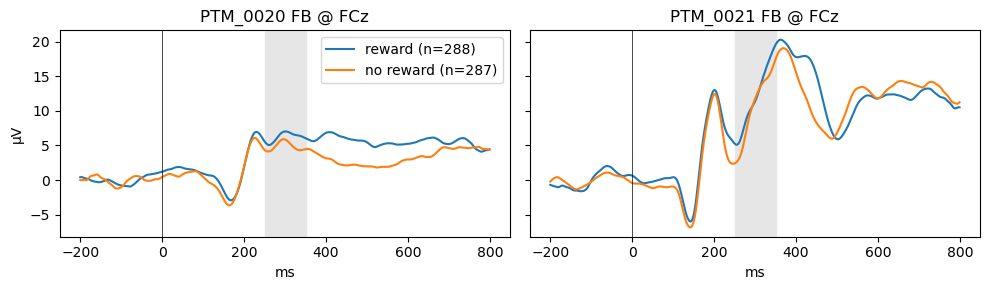

In [10]:
# If the matching is right, reward vs. no-reward feedback should differ around 250-350 ms at FCz.
import matplotlib.pyplot as plt

x = eeg["FB"].sel(channel="FCz")
fig, ax = plt.subplots(1, len(SUBJECTS), figsize=(5 * len(SUBJECTS), 3), sharey=True, squeeze=False)
for a, s in zip(ax[0], SUBJECTS):
    for r, lab in [(1, "reward"), (0, "no reward")]:
        keep = ((beh["FB"].subject == s) & (beh["FB"].reward == r)).values
        a.plot(x.time, x[keep].mean("trial"), label=f"{lab} (n={keep.sum()})")
    a.axvspan(250, 350, color="0.9"); a.axvline(0, c="k", lw=.5)
    a.set_title(f"PTM_{s} FB @ FCz"); a.set_xlabel("ms")
ax[0, 0].set_ylabel("µV"); ax[0, 0].legend()
plt.tight_layout()

## 8. Save

Per event: `PTM_<event>_eeg.npz` (`data` channel × trial × time, `channels`, `times`, `subject`, `trial`) and `PTM_<event>_behavior.csv` (same row order). Also `PTM_behavior_all_trials.csv` (all trials with `in_Cue` / `in_FB` flags) and `PTM_match_diagnostics.csv`.

In [10]:
for e in EVENTS:
    np.savez_compressed(OUT / f"PTM_{e}_eeg.npz",
                        data=eeg[e].values, channels=eeg[e].channel.values, times=eeg[e].time.values,
                        subject=eeg[e].subject.values, trial=eeg[e].trial_num.values)
    beh[e].to_csv(OUT / f"PTM_{e}_behavior.csv", index=False)
beh_full.to_csv(OUT / "PTM_behavior_all_trials.csv", index=False)
diag.to_csv(OUT / "PTM_match_diagnostics.csv", index=False)
print("saved to", OUT)

saved to C:\Yifan\thesis\PTM\study3\data\EEG_behav_trialwise


### Loading later (e.g. on another computer)

In [11]:
def load_matched(event, folder=OUT):
    z = np.load(Path(folder) / f"PTM_{event}_eeg.npz", allow_pickle=False)
    da = xr.DataArray(z["data"], dims=("channel", "trial", "time"),
                      coords={"channel": z["channels"], "time": z["times"],
                              "subject": ("trial", z["subject"]), "trial_num": ("trial", z["trial"])})
    b = pd.read_csv(Path(folder) / f"PTM_{event}_behavior.csv", dtype={"subject": str})
    assert (da.trial_num.values == b.trial.values).all()
    return da, b

# da, b = load_matched("FB")
# da.sel(channel="FCz", time=slice(250, 350)).mean("time")   # one value per trial, aligned with b